In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
def generate_ct_volume(shape=(128, 256, 256)):
    """
    Generate a synthetic CT volume with realistic Hounsfield Units.
    shape = (slices, height, width)
    """
    volume = np.full(shape, -1000, dtype=np.float32)  # air background
    
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    cz, cy, cx = shape[0]//2, shape[1]//2, shape[2]//2
    
    # ── body outline (ellipsoid) ─────────────────────────────────────
    body = ((z-cz)/50)**2 + ((y-cy)/90)**2 + ((x-cx)/70)**2 < 1
    volume[body] = 50  # soft tissue ~50 HU
    
    # ── spine (central bone column) ──────────────────────────────────
    spine = ((y-cy)/8)**2 + ((x-cx)/8)**2 < 1
    volume[spine & body] = 700  # bone ~700 HU
    
    # ── ribs (curved bone structures) ────────────────────────────────
    for i, zpos in enumerate(range(30, 100, 10)):
        angle = i * 0.3
        for t in np.linspace(0, np.pi, 60):
            rx = int(cx + 55 * np.cos(t) * np.cos(angle))
            ry = int(cy + 55 * np.sin(t))
            rz = int(zpos + 5 * np.sin(t * 2))
            if 0 <= rx < shape[2] and 0 <= ry < shape[1] and 0 <= rz < shape[0]:
                volume[max(0,rz-2):rz+2,
                       max(0,ry-2):ry+2,
                       max(0,rx-2):rx+2] = 700

    # ── lungs (low density ellipsoids) ───────────────────────────────
    lung_l = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx-25))/25)**2 < 1
    lung_r = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx+25))/25)**2 < 1
    volume[lung_l & body] = -500  # lung ~-500 HU
    volume[lung_r & body] = -500

    # ── liver (right side, mid-abdomen) ──────────────────────────────
    liver = ((z-(cz+15))/25)**2 + ((y-(cy+15))/30)**2 + ((x-(cx+20))/28)**2 < 1
    volume[liver & body] = 60  # liver ~60 HU

    # ── kidneys ──────────────────────────────────────────────────────
    kidney_l = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx-30))/10)**2 < 1
    kidney_r = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx+30))/10)**2 < 1
    volume[kidney_l & body] = 30  # kidney ~30 HU
    volume[kidney_r & body] = 30

    # ── aorta (central vessel) ────────────────────────────────────────
    aorta = ((y-(cy+5))/6)**2 + ((x-(cx-8))/6)**2 < 1
    volume[aorta & body] = 40  # blood ~40 HU

    # add realistic noise
    noise = np.random.normal(0, 15, shape).astype(np.float32)
    volume += noise
    
    # smooth slightly
    volume = ndimage.gaussian_filter(volume, sigma=0.8)
    
    return volume

print("Generating synthetic CT volume...")
np.random.seed(42)
volume = generate_ct_volume(shape=(128, 256, 256))

print(f"Volume shape: {volume.shape}")
print(f"  Slices (Z): {volume.shape[0]}")
print(f"  Height (Y): {volume.shape[1]}")
print(f"  Width  (X): {volume.shape[2]}")
print(f"\nHounsfield Unit statistics:")
print(f"  Min:  {volume.min():.1f} HU")
print(f"  Max:  {volume.max():.1f} HU")
print(f"  Mean: {volume.mean():.1f} HU")
print(f"\nMemory usage: {volume.nbytes / 1024**2:.1f} MB")

Generating synthetic CT volume...
Volume shape: (128, 256, 256)
  Slices (Z): 128
  Height (Y): 256
  Width  (X): 256

Hounsfield Unit statistics:
  Min:  -1020.1 HU
  Max:  710.4 HU
  Mean: -849.9 HU

Memory usage: 32.0 MB


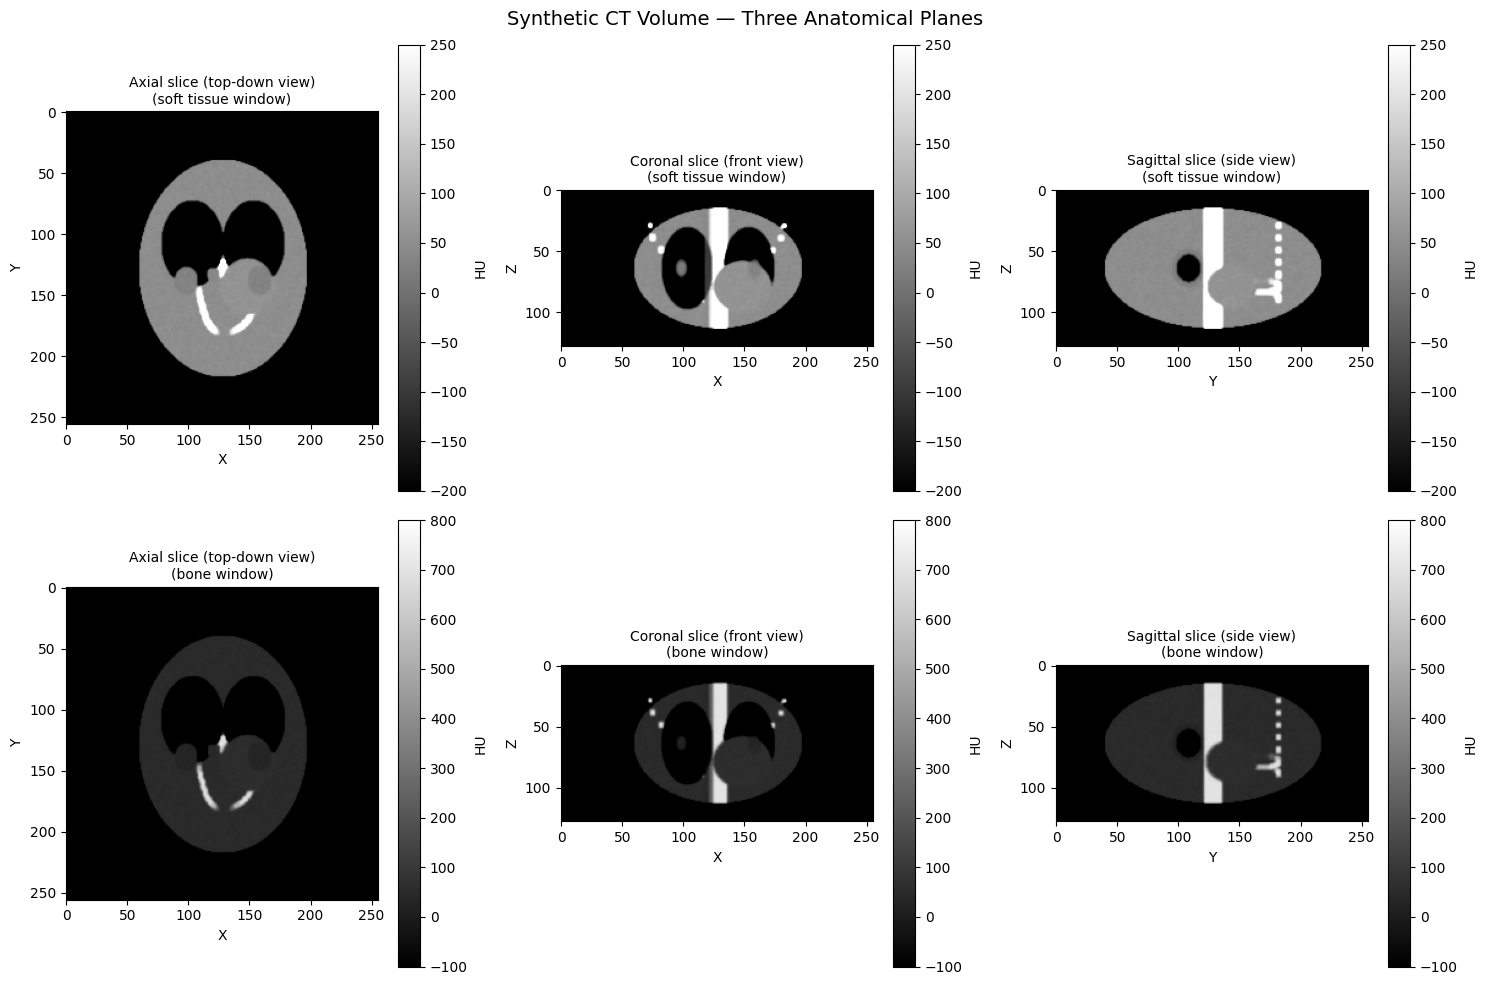

Saved to outputs/ct_slices.png


In [3]:
# three anatomical views — axial, coronal, sagittal
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

mid_z = volume.shape[0] // 2
mid_y = volume.shape[1] // 2
mid_x = volume.shape[2] // 2

views = [
    (volume[mid_z, :, :],   "Axial slice (top-down view)",      "X", "Y"),
    (volume[:, mid_y, :],   "Coronal slice (front view)",       "X", "Z"),
    (volume[:, :, mid_x],   "Sagittal slice (side view)",       "Y", "Z"),
]

# CT window presets
windows = [
    ("Soft tissue window\n(WL=50, WW=400)", 50-200, 50+200),
    ("Lung window\n(WL=-600, WW=1500)",    -600-750, -600+750),
    ("Bone window\n(WL=400, WW=1800)",      400-900, 400+900),
]

for col, (slice_data, title, xlabel, ylabel) in enumerate(views):
    for row, (win_title, vmin, vmax) in enumerate([(windows[0], windows[0][1], windows[0][2]),]):
        ax = axes[0, col]
        im = ax.imshow(slice_data, cmap='gray', vmin=-200, vmax=250,
                       aspect='equal', origin='upper')
        ax.set_title(f'{title}\n(soft tissue window)', fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.colorbar(im, ax=ax, label='HU')

# bone window views
for col, (slice_data, title, xlabel, ylabel) in enumerate(views):
    ax = axes[1, col]
    im = ax.imshow(slice_data, cmap='gray', vmin=-100, vmax=800,
                   aspect='equal', origin='upper')
    ax.set_title(f'{title}\n(bone window)', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax, label='HU')

plt.suptitle('Synthetic CT Volume — Three Anatomical Planes', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/ct_slices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/ct_slices.png")

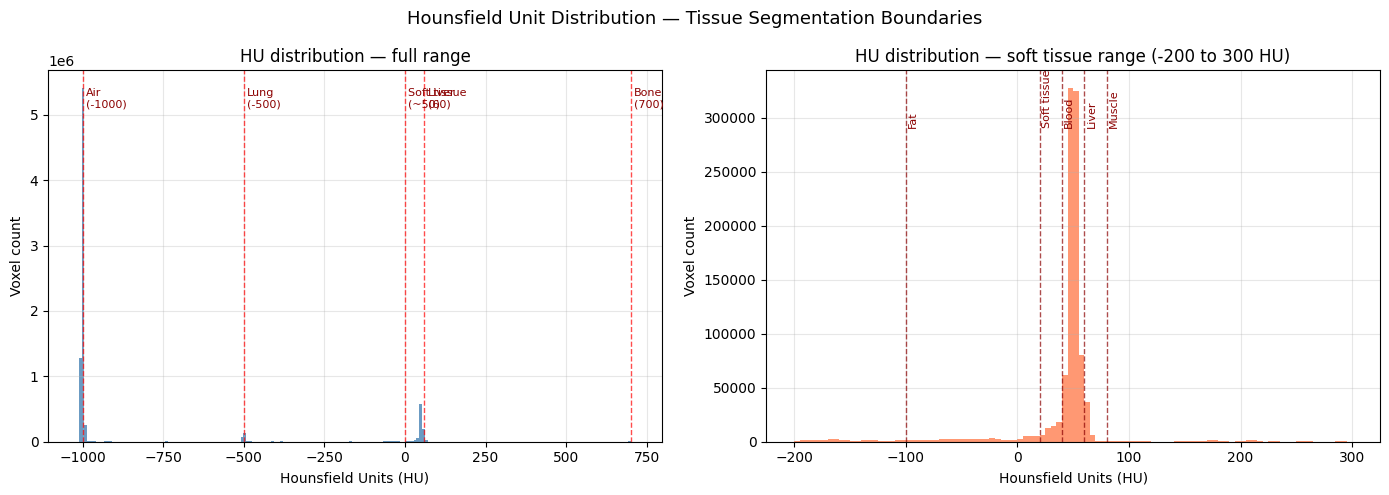

Saved to outputs/hu_distribution.png


In [4]:
# HU histogram — shows tissue density distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full range
axes[0].hist(volume.flatten(), bins=200, color='steelblue',
             edgecolor='none', alpha=0.8)
axes[0].set_title('HU distribution — full range')
axes[0].set_xlabel('Hounsfield Units (HU)')
axes[0].set_ylabel('Voxel count')
axes[0].grid(alpha=0.3)

# annotate tissue boundaries
tissue_ranges = [
    (-1000, 'Air\n(-1000)', '#87CEEB'),
    (-500,  'Lung\n(-500)', '#90EE90'),
    (0,     'Soft tissue\n(~50)', '#FFA07A'),
    (60,    'Liver\n(60)', '#DDA0DD'),
    (700,   'Bone\n(700)', '#F5F5DC'),
]
for hu, label, color in tissue_ranges:
    axes[0].axvline(x=hu, color='red', linestyle='--',
                    alpha=0.7, linewidth=1)
    axes[0].text(hu+10, axes[0].get_ylim()[1]*0.9,
                 label, fontsize=8, color='darkred')

# zoomed soft tissue range
mask = (volume.flatten() > -200) & (volume.flatten() < 300)
axes[1].hist(volume.flatten()[mask], bins=100,
             color='coral', edgecolor='none', alpha=0.8)
axes[1].set_title('HU distribution — soft tissue range (-200 to 300 HU)')
axes[1].set_xlabel('Hounsfield Units (HU)')
axes[1].set_ylabel('Voxel count')
axes[1].grid(alpha=0.3)

for hu, label, _ in [(-100,'Fat',-1),(20,'Soft tissue',-1),
                      (40,'Blood',-1),(60,'Liver',-1),(80,'Muscle',-1)]:
    axes[1].axvline(x=hu, color='darkred', linestyle='--',
                    alpha=0.7, linewidth=1)
    axes[1].text(hu+2, axes[1].get_ylim()[1]*0.85,
                 label, fontsize=8, color='darkred', rotation=90)

plt.suptitle('Hounsfield Unit Distribution — Tissue Segmentation Boundaries',
             fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/hu_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/hu_distribution.png")

In [2]:
import numpy as np

data = np.load('../data/full_archive.npz', allow_pickle=True)
print("NPZ contents:")
for key in data.files:
    arr = data[key]
    print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")
    try:
        print(f"    min={arr.min():.1f}, max={arr.max():.1f}")
    except:
        print(f"    (non-numeric array)")
        if arr.ndim == 0:
            print(f"    value: {arr.item()}")
        else:
            print(f"    first element: {arr.flat[0]}")

NPZ contents:


C:\Users\hidey\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


  image: shape=(475,), dtype=object
    (non-numeric array)
    first element: [[ -973.  -997. -1024. ...  -993.  -979.  -995.]
 [ -985.  -977. -1023. ...  -964. -1024. -1022.]
 [ -973. -1019. -1014. ... -1024.  -942.  -961.]
 ...
 [-1024.  -971.  -935. ... -1023.  -989.  -994.]
 [ -954.  -928. -1024. ...  -965. -1024.  -980.]
 [ -997.  -996. -1024. ...  -882.  -973. -1001.]]
  idx: shape=(475,), dtype=int64
    min=0.0, max=588.0


In [3]:
import numpy as np
import pandas as pd

data = np.load('../data/full_archive.npz', allow_pickle=True)
images = data['image']
idx = data['idx']

# check overview CSV
df = pd.read_csv('../data/overview.csv')
print("Overview CSV columns:", df.columns.tolist())
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nUnique patient IDs: {df['id'].nunique() if 'id' in df.columns else 'check columns'}")

C:\Users\hidey\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Overview CSV columns: ['Unnamed: 0', 'Age', 'Contrast', 'ContrastTag', 'raw_input_path', 'id', 'tiff_name', 'dicom_name']

First few rows:
   Unnamed: 0  Age  Contrast ContrastTag  \
0           0   60      True        NONE   
1           1   69      True        NONE   
2           2   74      True     APPLIED   
3           3   75      True        NONE   
4           4   56      True        NONE   
5           5   48      True        NONE   
6           6   75      True        NONE   
7           7   61      True        NONE   
8           8   51      True         NaN   
9           9   48      True        NONE   

                                      raw_input_path  id  \
0   ../data/50_50_dicom_cases\Contrast\00001 (1).dcm   0   
1  ../data/50_50_dicom_cases\Contrast\00001 (10).dcm   1   
2  ../data/50_50_dicom_cases\Contrast\00001 (11).dcm   2   
3  ../data/50_50_dicom_cases\Contrast\00001 (12).dcm   3   
4  ../data/50_50_dicom_cases\Contrast\00001 (13).dcm   4   
5  ../data/50_50

In [4]:
# check how many slices belong to the same patient case
print("Slice distribution:")
print(f"Total slices: {len(images)}")
print(f"Total patients: {len(df)}")
print(f"Slices per patient: {len(images)/len(df):.1f} average")

# look at the raw_input_path to find cases with most slices
df['case'] = df['raw_input_path'].str.extract(r'\\(\d+)\s*\(')
case_counts = df['case'].value_counts()
print(f"\nSlices per case (top 5):")
print(case_counts.head())

# load all slices and check their shapes
print(f"\nFirst 3 slice shapes:")
for i in range(3):
    print(f"  Slice {i}: {images[i].shape}")

Slice distribution:
Total slices: 475
Total patients: 100
Slices per patient: 4.8 average

Slices per case (top 5):
case
00001     50
000001    50
Name: count, dtype: int64

First 3 slice shapes:
  Slice 0: (512, 512)
  Slice 1: (512, 512)
  Slice 2: (512, 512)


In [5]:
# get all slices from case 00001
case_mask = df['case'] == '00001'
case_indices = df[case_mask].index.tolist()

print(f"Case 00001: {len(case_indices)} slices")

# stack into 3D volume
slices = [images[i] for i in case_indices]
volume_real = np.stack(slices, axis=0).astype(np.float32)

print(f"Volume shape: {volume_real.shape}")
print(f"HU range: {volume_real.min():.1f} to {volume_real.max():.1f}")
print(f"Memory: {volume_real.nbytes/1024**2:.1f} MB")

# save for use in other notebooks
np.save('../data/real_volume.npy', volume_real)
print("\nSaved to data/real_volume.npy")

Case 00001: 50 slices
Volume shape: (50, 512, 512)
HU range: -1024.0 to 3071.0
Memory: 50.0 MB

Saved to data/real_volume.npy


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

mid_z = volume_real.shape[0] // 2

views = [
    (volume_real[mid_z],      "Axial — middle slice"),
    (volume_real[mid_z-10],   "Axial — upper slice"),
    (volume_real[mid_z+10],   "Axial — lower slice"),
    (volume_real[:, 256, :],  "Coronal view"),
    (volume_real[:, :, 256],  "Sagittal view"),
]

for idx, (slice_data, title) in enumerate(views):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    ax.imshow(slice_data, cmap='gray', vmin=-200, vmax=300,
              aspect='equal', origin='upper')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

# HU histogram
axes[1, 2].hist(volume_real.flatten(), bins=100,
                color='steelblue', edgecolor='none', alpha=0.8)
axes[1, 2].set_title('HU distribution')
axes[1, 2].set_xlabel('Hounsfield Units')
axes[1, 2].set_ylabel('Voxel count')
axes[1, 2].grid(alpha=0.3)
for hu, label in [(-500,'Lung'),(-100,'Fat'),(50,'Soft'),(400,'Bone')]:
    axes[1, 2].axvline(x=hu, color='red', linestyle='--',
                       alpha=0.7, linewidth=1)
    axes[1, 2].text(hu+10, axes[1,2].get_ylim()[1]*0.8,
                    label, fontsize=8, color='darkred', rotation=90)

plt.suptitle('Real CT Data — Case 00001', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/real_ct_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/real_ct_slices.png")

NameError: name 'plt' is not defined

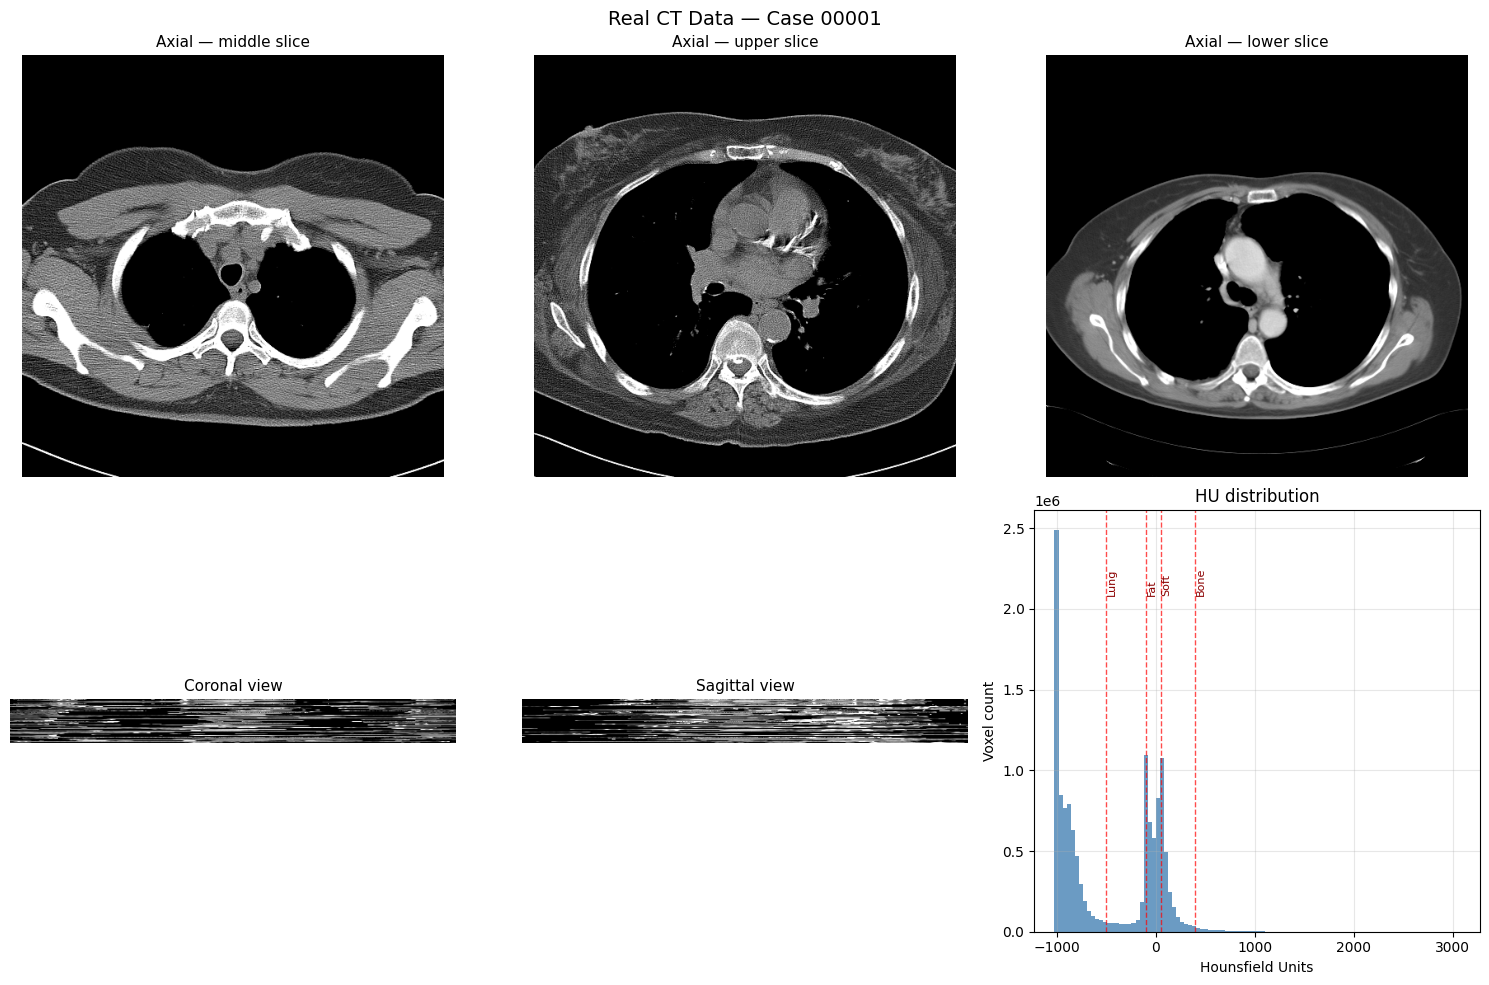

Saved to outputs/real_ct_slices.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# reload the real volume
volume_real = np.load('../data/real_volume.npy')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

mid_z = volume_real.shape[0] // 2

views = [
    (volume_real[mid_z],      "Axial — middle slice"),
    (volume_real[mid_z-10],   "Axial — upper slice"),
    (volume_real[mid_z+10],   "Axial — lower slice"),
    (volume_real[:, 256, :],  "Coronal view"),
    (volume_real[:, :, 256],  "Sagittal view"),
]

for idx, (slice_data, title) in enumerate(views):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    ax.imshow(slice_data, cmap='gray', vmin=-200, vmax=300,
              aspect='equal', origin='upper')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

# HU histogram
axes[1, 2].hist(volume_real.flatten(), bins=100,
                color='steelblue', edgecolor='none', alpha=0.8)
axes[1, 2].set_title('HU distribution')
axes[1, 2].set_xlabel('Hounsfield Units')
axes[1, 2].set_ylabel('Voxel count')
axes[1, 2].grid(alpha=0.3)
for hu, label in [(-500,'Lung'),(-100,'Fat'),(50,'Soft'),(400,'Bone')]:
    axes[1, 2].axvline(x=hu, color='red', linestyle='--',
                       alpha=0.7, linewidth=1)
    axes[1, 2].text(hu+10, axes[1,2].get_ylim()[1]*0.8,
                    label, fontsize=8, color='darkred', rotation=90)

plt.suptitle('Real CT Data — Case 00001', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/real_ct_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/real_ct_slices.png")

Segmenting real CT volume...
Bone voxels:  235,276
Lung voxels:  5,924,542

Applying Marching Cubes...
Bone mesh:  27,504 vertices, 53,524 faces
Lung mesh:  297,929 vertices, 596,442 faces


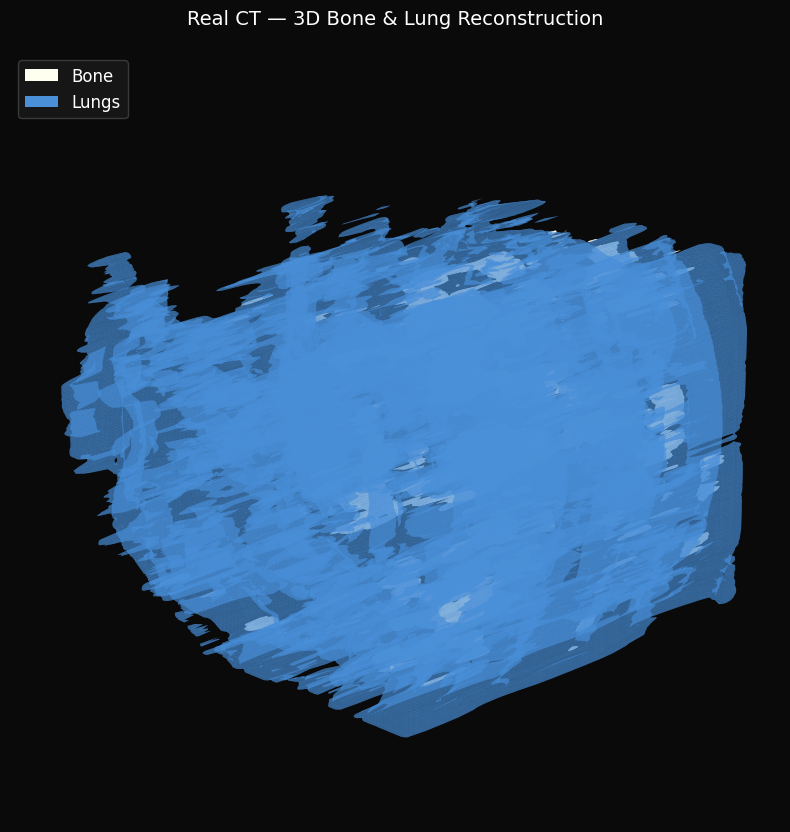


Saved to outputs/real_3d_reconstruction.png


In [8]:
from scipy import ndimage
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

print("Segmenting real CT volume...")

# segment bones
bone_mask = volume_real > 350
bone_mask = ndimage.binary_closing(bone_mask, iterations=2)
bone_mask = ndimage.binary_fill_holes(bone_mask)

# segment lungs
lung_mask = (volume_real > -900) & (volume_real < -300)
labeled, n = ndimage.label(lung_mask)
sizes = ndimage.sum(lung_mask, labeled, range(1, n+1))
large = [i+1 for i, s in enumerate(sizes) if s > 1000]
lung_mask = np.isin(labeled, large)
lung_mask = ndimage.binary_closing(lung_mask, iterations=3)
lung_mask = ndimage.binary_fill_holes(lung_mask)

print(f"Bone voxels:  {bone_mask.sum():,}")
print(f"Lung voxels:  {lung_mask.sum():,}")

# marching cubes
print("\nApplying Marching Cubes...")

smoothed_bone = ndimage.gaussian_filter(bone_mask.astype(float), sigma=1.0)
bone_verts, bone_faces, _, _ = measure.marching_cubes(
    smoothed_bone, level=0.5, step_size=2)

smoothed_lung = ndimage.gaussian_filter(lung_mask.astype(float), sigma=1.5)
lung_verts, lung_faces, _, _ = measure.marching_cubes(
    smoothed_lung, level=0.5, step_size=2)

print(f"Bone mesh:  {len(bone_verts):,} vertices, {len(bone_faces):,} faces")
print(f"Lung mesh:  {len(lung_verts):,} vertices, {len(lung_faces):,} faces")

# render
fig = plt.figure(figsize=(12, 10), facecolor='#0a0a0a')
ax = fig.add_subplot(111, projection='3d', facecolor='#0a0a0a')

bone_mesh = Poly3DCollection(bone_verts[bone_faces],
                              alpha=0.85, linewidth=0)
bone_mesh.set_facecolor('#FFFFF0')
bone_mesh.set_edgecolor('none')
ax.add_collection3d(bone_mesh)

lung_mesh = Poly3DCollection(lung_verts[lung_faces],
                              alpha=0.5, linewidth=0)
lung_mesh.set_facecolor('#4A90D9')
lung_mesh.set_edgecolor('none')
ax.add_collection3d(lung_mesh)

all_verts = np.vstack([bone_verts, lung_verts])
ax.set_xlim(all_verts[:,0].min(), all_verts[:,0].max())
ax.set_ylim(all_verts[:,1].min(), all_verts[:,1].max())
ax.set_zlim(all_verts[:,2].min(), all_verts[:,2].max())
ax.view_init(elev=20, azim=45)
ax.set_axis_off()

from matplotlib.patches import Patch
legend = [Patch(facecolor='#FFFFF0', label='Bone'),
          Patch(facecolor='#4A90D9', label='Lungs')]
ax.legend(handles=legend, loc='upper left',
          labelcolor='white', facecolor='#1a1a1a',
          edgecolor='#444', fontsize=12)

ax.set_title('Real CT — 3D Bone & Lung Reconstruction',
             color='white', fontsize=14, pad=20)

plt.savefig('../outputs/real_3d_reconstruction.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a0a')
plt.show()
print("\nSaved to outputs/real_3d_reconstruction.png")